In [1]:
pip install pandas statistics seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import statistics as sts

Matplotlib created a temporary cache directory at /tmp/matplotlib-gkboao1q because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
df = pd.read_csv(r'dataset_parque_fabril_weg.csv',
                 sep=";")

In [4]:
df.head()

,ID_Equipamento,Planta_WEG,Linha_Producao,Turno_Trabalho,Horas_Operacao_Acumuladas,Tempo_Operacao_Anos,Temperatura_Estator_C,Vibracao_Mancal_mms,Pressao_Impregnacao_VPI_bar,Score_Confiabilidade,Contrato_Manutencao,Custo_Manutencao_Anual_RS,Parada_Nao_Programada
0,WEG-EQP-00001,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),13191.3,15,70.1,11.20,5.45,529.0,1,115325.56,1
1,WEG-EQP-00002,Linhares (ES),W22 Magnet,Turno 2 (14:18-23:30),7889.6,4,69.1,6.76,8.29,665.0,1,84664.64,1
2,WEG-EQP-00003,Guaramirim (SC),W50 - Alta Tensão,Turno 2 (14:18-23:30),37611.5,5,72.1,2.55,6.89,694.0,1,90032.94,0
3,WEG-EQP-00004,Blumenau (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),24603.6,14,83.7,13.68,5.36,591.0,1,142879.69,0
4,WEG-EQP-00005,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),60458.4,5,71.3,3.33,10.58,609.0,1,89678.02,0


In [5]:
df.shape

(10000, 13)

In [6]:
df.columns = ["Id", "Planta", "Linha", "Turno", "Horas_Operacao", "Tempo_Operacao_Anos", "Temperatura", "Vibracao", "Pressao_VPI", "Confiabilidade", "Contrato_Manutencao", "Custo_Manutencao", "Parada_Nao_Programada"]

In [7]:
df.groupby(["Planta"]).size()

Planta
Blumenau (SC)          1997
Desconhecido            128
Guaramirim (SC)        1408
Invalido_XX             135
Jaraguá do Sul (SC)    4533
Linhares (ES)           516
São Bernardo (SP)      1163
dtype: int64

<Axes: xlabel='Planta'>

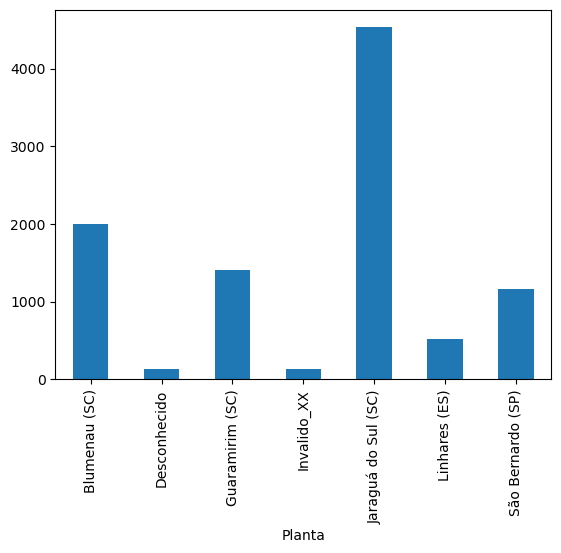

In [8]:
df.groupby(["Planta"]).size().plot.bar()

In [9]:
df.groupby(["Linha"]).size()

Linha
Mono                            196
Tri                             223
W12 - Comercial/Residencial    1529
W22 - Trifásico Standard       4462
W22 Magnet                      761
W22-STD                         189
W50 - Alta Tensão              1886
W60 - Grande Porte              604
dtype: int64

<Axes: xlabel='Linha'>

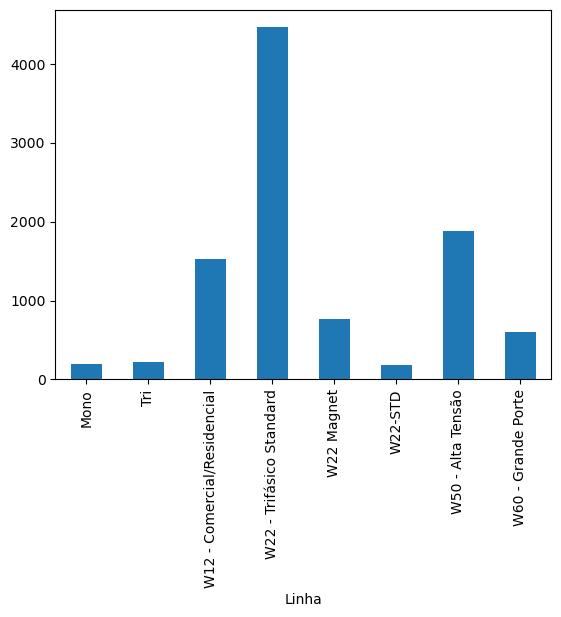

In [10]:
df.groupby(["Linha"]).size().plot.bar()

In [11]:
df.groupby(["Turno"]).size()

Turno
Turno 1 (05:00-14:18)    4429
Turno 2 (14:18-23:30)    3884
Turno 3 (23:30-05:00)    1687
dtype: int64

<Axes: xlabel='Turno'>

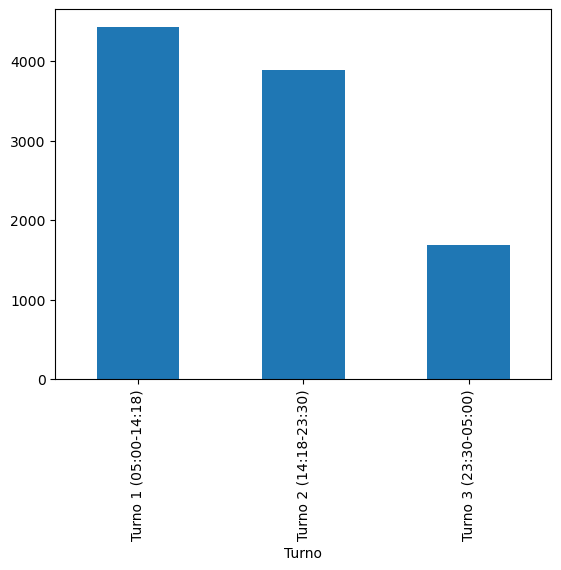

In [12]:
df.groupby(["Turno"]).size().plot.bar()

In [13]:
df[df.duplicated(["Id"], keep=False)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada


In [14]:
df.drop_duplicates(subset="Id", keep="first", inplace=True)

In [15]:
df["Planta"].isnull().sum()

np.int64(120)

In [16]:
df["Linha"].isnull().sum()

np.int64(150)

In [17]:
df["Horas_Operacao"].isnull().sum()

np.int64(180)

In [18]:
df["Temperatura"].isnull().sum()

np.int64(210)

In [19]:
df["Vibracao"].isnull().sum()

np.int64(190)

In [20]:
df["Pressao_VPI"].isnull().sum()

np.int64(220)

In [21]:
df["Confiabilidade"].isnull().sum()

np.int64(160)

In [22]:
df["Custo_Manutencao"].isnull().sum()

np.int64(199)

In [23]:
df["Horas_Operacao"].describe()

count    9.820000e+03
mean     2.672526e+04
std      6.058830e+04
min     -5.000000e+02
25%      1.362855e+04
50%      2.124865e+04
75%      3.137150e+04
max      1.500000e+06
Name: Horas_Operacao, dtype: float64

In [24]:
df["Tempo_Operacao_Anos"].describe()

count    10000.000000
mean        12.603500
std          8.041676
min         -2.000000
25%          7.000000
50%         12.500000
75%         18.000000
max        120.000000
Name: Tempo_Operacao_Anos, dtype: float64

In [25]:
df["Temperatura"].describe()

count    9790.000000
mean       74.997283
std        11.970719
min        30.400000
25%        66.800000
50%        75.100000
75%        83.000000
max       119.700000
Name: Temperatura, dtype: float64

In [26]:
df["Vibracao"].describe()

count    9810.000000
mean        2.711895
std         2.188805
min         0.500000
25%         1.130000
50%         2.030000
75%         3.600000
max        18.590000
Name: Vibracao, dtype: float64

In [27]:
df["Pressao_VPI"].describe()

count    9780.000000
mean        7.477819
std         1.492717
min         2.070000
25%         6.480000
50%         7.500000
75%         8.460000
max        14.540000
Name: Pressao_VPI, dtype: float64

In [28]:
df["Confiabilidade"].describe()

count    9840.000000
mean      678.244309
std        84.808644
min       120.000000
25%       623.000000
50%       679.000000
75%       736.000000
max      1050.000000
Name: Confiabilidade, dtype: float64

In [29]:
df["Custo_Manutencao"].describe()

count    9.801000e+03
mean     9.734844e+04
std      2.793549e+05
min     -1.500000e+04
25%      7.725085e+04
50%      8.676090e+04
75%      9.680037e+04
max      9.999999e+06
Name: Custo_Manutencao, dtype: float64

In [30]:
df.loc[df["Planta"].isnull(), "Planta"] = "Jaraguá do Sul (SC)"
df.loc[df["Linha"].isnull(), "Linha"] = "W22 - Trifásico Standard"

df.loc[df["Planta"].isin(["Desconhecido", "Invalido_XX"]), "Planta"] = "Jaraguá do Sul (SC)"

df.loc[df["Linha"].isin(["W22-STD", "Tri"]), "Linha"] = "W22 - Trifásico Standard"
df.loc[df["Linha"].isin(["Mono"]), "Linha"] = "W12 - Comercial/Residencial"

In [31]:
df.loc[df["Horas_Operacao"].isnull(), "Horas_Operacao"] = 21248.65
df.loc[df["Temperatura"].isnull(), "Temperatura"] = 75.1
df.loc[df["Vibracao"].isnull(), "Vibracao"] = 2.03
df.loc[df["Pressao_VPI"].isnull(), "Pressao_VPI"] = 7.5
df.loc[df["Confiabilidade"].isnull(), "Confiabilidade"] = 679
df.loc[df["Custo_Manutencao"].isnull(), "Custo_Manutencao"] = 86760.9

In [32]:
df.loc[(df["Horas_Operacao"] > 100000) | (df["Horas_Operacao"] < 0)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
195,WEG-EQP-00196,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),1500000.0,14,86.2,1.70,8.18,773.0,1,76452.08,0
442,WEG-EQP-00443,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),999999.0,12,76.0,0.60,7.70,628.0,0,77656.11,1
493,WEG-EQP-00494,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),-500.0,20,75.6,6.36,6.29,713.0,1,101215.96,1
540,WEG-EQP-00541,Linhares (ES),W50 - Alta Tensão,Turno 1 (05:00-14:18),1500000.0,7,72.0,2.59,9.49,622.0,1,104012.34,0
671,WEG-EQP-00672,São Bernardo (SP),W22 - Trifásico Standard,Turno 1 (05:00-14:18),-500.0,11,70.7,2.75,5.91,719.0,1,80722.93,0
1306,WEG-EQP-01307,Guaramirim (SC),W50 - Alta Tensão,Turno 2 (14:18-23:30),-500.0,20,80.9,0.76,6.17,728.0,1,89092.77,0
1781,WEG-EQP-01782,São Bernardo (SP),W50 - Alta Tensão,Turno 2 (14:18-23:30),999999.0,16,80.7,3.29,8.25,712.0,1,89597.39,1
1994,WEG-EQP-01995,Guaramirim (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),1500000.0,21,70.0,2.07,7.50,590.0,0,93042.92,1
2733,WEG-EQP-02734,Linhares (ES),W22 - Trifásico Standard,Turno 2 (14:18-23:30),999999.0,7,72.2,5.21,7.97,691.0,0,86760.90,0
2805,WEG-EQP-02806,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),-500.0,14,81.7,2.22,3.37,626.0,1,81895.34,1


In [33]:
df.loc[(df["Horas_Operacao"] > 100000) | (df["Horas_Operacao"] < 0), "Horas_Operacao"] = sts.median(df["Horas_Operacao"])

In [34]:
df.loc[(df["Tempo_Operacao_Anos"] > 50) | (df["Tempo_Operacao_Anos"] < 0)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
216,WEG-EQP-00217,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),3285.7,-2,73.1,3.44,4.58,754.0,1,79135.14,0
852,WEG-EQP-00853,Jaraguá do Sul (SC),W22 Magnet,Turno 2 (14:18-23:30),40366.1,-2,70.6,2.21,6.97,615.0,0,97102.67,0
1377,WEG-EQP-01378,Blumenau (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),23723.3,105,81.5,3.26,8.52,674.0,1,77940.48,0
2043,WEG-EQP-02044,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),7325.3,120,87.9,0.97,7.96,734.0,1,72257.50,0
2338,WEG-EQP-02339,Jaraguá do Sul (SC),W60 - Grande Porte,Turno 1 (05:00-14:18),22651.9,-2,97.1,5.18,6.41,741.0,1,94584.60,0
2386,WEG-EQP-02387,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 3 (23:30-05:00),11070.6,-2,67.0,1.85,7.63,525.0,1,61320.93,0
2387,WEG-EQP-02388,Blumenau (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),26969.6,105,70.6,0.88,7.01,743.0,0,80563.58,1
2613,WEG-EQP-02614,Guaramirim (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),24707.2,105,64.7,1.01,7.07,646.0,1,75994.59,0
2939,WEG-EQP-02940,Jaraguá do Sul (SC),W60 - Grande Porte,Turno 2 (14:18-23:30),39040.5,120,48.4,0.84,9.40,657.0,1,69024.02,0
3503,WEG-EQP-03504,Jaraguá do Sul (SC),W22 Magnet,Turno 1 (05:00-14:18),19019.0,105,75.9,0.85,7.31,693.0,1,55972.86,0


In [35]:
df.loc[(df["Tempo_Operacao_Anos"] > 50) | (df["Tempo_Operacao_Anos"] < 0), "Tempo_Operacao_Anos"] = sts.median(df["Tempo_Operacao_Anos"])

C:\Users\guilherme_doge1\AppData\Local\Temp\ipykernel_18136\2320985468.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Tempo_Operacao_Anos"] > 50) | (df["Tempo_Operacao_Anos"] < 0), "Tempo_Operacao_Anos"] = sts.median(df["Tempo_Operacao_Anos"])


In [36]:
df.loc[(df["Confiabilidade"] > 1000) | (df["Confiabilidade"] < 0)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
4436,WEG-EQP-04437,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),42277.3,13.0,70.3,6.53,9.14,1050.0,1,87973.64,0
5960,WEG-EQP-05961,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),15388.7,5.0,50.8,1.92,6.74,1050.0,1,71522.49,0
6123,WEG-EQP-06124,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),18280.9,16.0,60.1,1.84,4.80,1050.0,0,66162.43,0
7064,WEG-EQP-07065,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),12419.0,24.0,75.4,3.24,6.99,1050.0,0,73729.22,0
8071,WEG-EQP-08072,Jaraguá do Sul (SC),W60 - Grande Porte,Turno 1 (05:00-14:18),26362.1,12.0,70.2,1.21,6.75,1050.0,0,46888.63,1


In [37]:
df.loc[(df["Confiabilidade"] > 1000) | (df["Confiabilidade"] < 0), "Confiabilidade"] = sts.median(df["Confiabilidade"])

In [38]:
df.loc[(df["Custo_Manutencao"] > 500000) | (df["Custo_Manutencao"] < 0)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
645,WEG-EQP-00646,São Bernardo (SP),W22 - Trifásico Standard,Turno 2 (14:18-23:30),18686.0,9.0,101.2,3.41,10.65,677.0,0,2500000.0,1
1311,WEG-EQP-01312,São Bernardo (SP),W22 - Trifásico Standard,Turno 3 (23:30-05:00),63908.7,5.0,69.7,3.61,4.58,747.0,1,-15000.0,0
1405,WEG-EQP-01406,Blumenau (SC),W12 - Comercial/Residencial,Turno 1 (05:00-14:18),20830.8,12.0,98.0,1.24,4.90,659.0,0,2500000.0,1
1667,WEG-EQP-01668,Linhares (ES),W22 - Trifásico Standard,Turno 3 (23:30-05:00),24250.0,17.0,98.2,2.05,8.78,772.0,1,2500000.0,0
2566,WEG-EQP-02567,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 3 (23:30-05:00),17004.6,17.0,79.1,0.57,7.01,720.0,0,2500000.0,1
2830,WEG-EQP-02831,Blumenau (SC),W50 - Alta Tensão,Turno 1 (05:00-14:18),19986.5,18.0,78.0,5.72,4.87,639.0,1,-15000.0,0
3103,WEG-EQP-03104,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),5015.8,15.0,77.5,4.31,8.59,711.0,0,2500000.0,0
3484,WEG-EQP-03485,Blumenau (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),18915.8,10.0,69.2,1.37,9.26,739.0,1,2500000.0,0
3765,WEG-EQP-03766,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 3 (23:30-05:00),18369.0,8.0,88.3,4.60,8.39,633.0,1,-15000.0,0
3962,WEG-EQP-03963,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),21889.3,4.0,90.8,3.40,8.31,694.0,1,9999999.0,1


In [39]:
df.loc[(df["Custo_Manutencao"] > 500000) | (df["Custo_Manutencao"] < 0), "Custo_Manutencao"] = sts.median(df["Custo_Manutencao"])

In [40]:
df.loc[(df["Temperatura"] > 85) | (df["Temperatura"] < 65)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
7,WEG-EQP-00008,São Bernardo (SP),W50 - Alta Tensão,Turno 3 (23:30-05:00),15191.9,2.0,86.9,1.28,6.09,586.0,1,86760.90,0
8,WEG-EQP-00009,Blumenau (SC),W22 Magnet,Turno 2 (14:18-23:30),32929.5,2.0,63.8,2.43,7.67,635.0,1,79109.13,0
11,WEG-EQP-00012,Linhares (ES),W22 - Trifásico Standard,Turno 1 (05:00-14:18),22133.2,2.0,47.0,4.14,7.22,719.0,1,89178.87,1
12,WEG-EQP-00013,São Bernardo (SP),W22 - Trifásico Standard,Turno 2 (14:18-23:30),42893.0,21.0,62.2,5.09,7.65,697.0,1,80234.12,1
18,WEG-EQP-00019,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),42692.7,22.0,104.0,0.58,8.41,600.0,1,81693.66,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,WEG-EQP-09988,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),20075.6,2.0,86.9,2.43,9.19,771.0,1,69663.49,0
9989,WEG-EQP-09990,São Bernardo (SP),W22 Magnet,Turno 3 (23:30-05:00),16697.3,19.0,59.0,0.87,5.31,595.0,1,98913.16,0
9996,WEG-EQP-09997,São Bernardo (SP),W22 - Trifásico Standard,Turno 2 (14:18-23:30),18915.1,12.0,61.8,1.04,7.68,566.0,1,86760.90,0
9997,WEG-EQP-09998,Linhares (ES),W22 - Trifásico Standard,Turno 1 (05:00-14:18),19170.0,23.0,57.8,0.74,10.12,488.0,1,52159.07,0


In [41]:
df.loc[df["Vibracao"] > 4.5]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
0,WEG-EQP-00001,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),13191.3,15.0,70.1,11.20,5.45,529.0,1,115325.56,1
1,WEG-EQP-00002,Linhares (ES),W22 Magnet,Turno 2 (14:18-23:30),7889.6,4.0,69.1,6.76,8.29,665.0,1,84664.64,1
3,WEG-EQP-00004,Blumenau (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),24603.6,14.0,83.7,13.68,5.36,591.0,1,142879.69,0
12,WEG-EQP-00013,São Bernardo (SP),W22 - Trifásico Standard,Turno 2 (14:18-23:30),42893.0,21.0,62.2,5.09,7.65,697.0,1,80234.12,1
13,WEG-EQP-00014,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),7092.9,23.0,80.0,4.70,6.52,581.0,1,101367.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,WEG-EQP-09981,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 1 (05:00-14:18),5122.8,2.0,52.5,10.49,9.97,643.0,0,92339.06,0
9981,WEG-EQP-09982,Blumenau (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),10859.8,3.0,91.1,9.76,8.91,759.0,1,122046.07,0
9985,WEG-EQP-09986,Blumenau (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),34029.4,10.0,104.3,10.98,5.03,591.0,1,114596.51,1
9991,WEG-EQP-09992,Jaraguá do Sul (SC),W22 Magnet,Turno 2 (14:18-23:30),51531.9,9.0,71.1,6.67,6.32,628.0,1,117844.07,0


In [42]:
df.loc[(df["Pressao_VPI"] > 6) | (df["Pressao_VPI"] < 4.5)]

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
1,WEG-EQP-00002,Linhares (ES),W22 Magnet,Turno 2 (14:18-23:30),7889.6,4.0,69.1,6.76,8.29,665.0,1,84664.64,1
2,WEG-EQP-00003,Guaramirim (SC),W50 - Alta Tensão,Turno 2 (14:18-23:30),37611.5,5.0,72.1,2.55,6.89,694.0,1,90032.94,0
4,WEG-EQP-00005,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),60458.4,5.0,71.3,3.33,10.58,609.0,1,89678.02,0
5,WEG-EQP-00006,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 1 (05:00-14:18),31083.5,7.0,75.1,3.15,6.52,690.0,1,79967.62,0
6,WEG-EQP-00007,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),11867.5,14.0,65.1,0.73,6.87,710.0,1,75525.11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,WEG-EQP-09994,São Bernardo (SP),W50 - Alta Tensão,Turno 3 (23:30-05:00),18454.2,19.0,74.3,8.33,8.13,734.0,1,107457.28,0
9994,WEG-EQP-09995,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),43687.6,3.0,84.1,1.63,9.76,759.0,0,104581.07,0
9996,WEG-EQP-09997,São Bernardo (SP),W22 - Trifásico Standard,Turno 2 (14:18-23:30),18915.1,12.0,61.8,1.04,7.68,566.0,1,86760.90,0
9997,WEG-EQP-09998,Linhares (ES),W22 - Trifásico Standard,Turno 1 (05:00-14:18),19170.0,23.0,57.8,0.74,10.12,488.0,1,52159.07,0


In [43]:
df.groupby(["Id"]).size().describe()

count    10000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

In [44]:
df.groupby(["Turno", "Parada_Nao_Programada"]).size()

Turno                  Parada_Nao_Programada
Turno 1 (05:00-14:18)  0                        3731
                       1                         698
Turno 2 (14:18-23:30)  0                        3251
                       1                         633
Turno 3 (23:30-05:00)  0                        1423
                       1                         264
dtype: int64

<Axes: xlabel='Turno,Parada_Nao_Programada'>

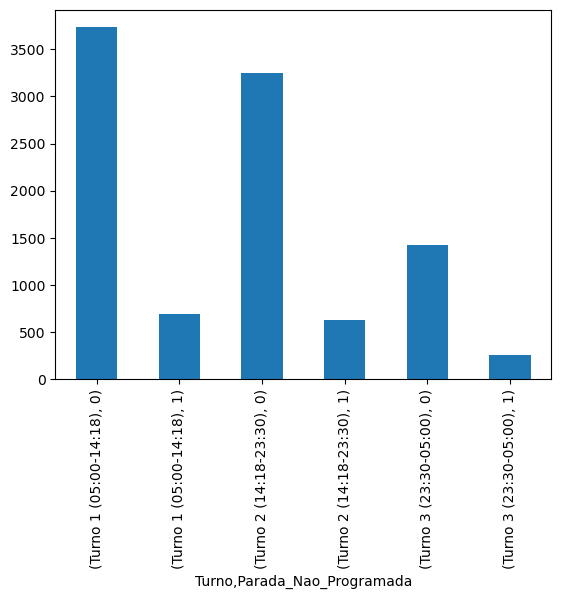

In [45]:
df.groupby(["Turno", "Parada_Nao_Programada"]).size().plot.bar()

In [46]:
df.groupby(["Linha", "Parada_Nao_Programada"]).size()

Linha                        Parada_Nao_Programada
W12 - Comercial/Residencial  0                        1438
                             1                         287
W22 - Trifásico Standard     0                        4240
                             1                         784
W22 Magnet                   0                         658
                             1                         103
W50 - Alta Tensão            0                        1574
                             1                         312
W60 - Grande Porte           0                         495
                             1                         109
dtype: int64

<Axes: xlabel='Linha,Parada_Nao_Programada'>

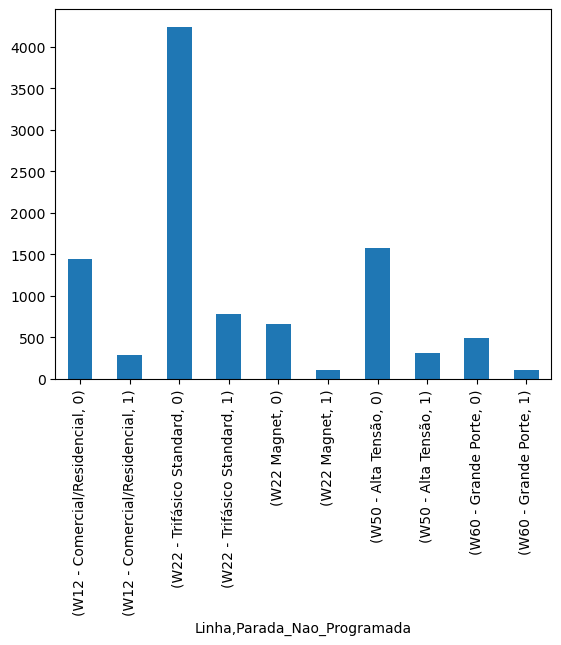

In [47]:
df.groupby(["Linha", "Parada_Nao_Programada"]).size().plot.bar()

In [48]:
df.groupby(["Planta", "Parada_Nao_Programada"]).size()

Planta               Parada_Nao_Programada
Blumenau (SC)        0                        1687
                     1                         310
Guaramirim (SC)      0                        1176
                     1                         232
Jaraguá do Sul (SC)  0                        4135
                     1                         781
Linhares (ES)        0                         427
                     1                          89
São Bernardo (SP)    0                         980
                     1                         183
dtype: int64

<Axes: xlabel='Planta,Parada_Nao_Programada'>

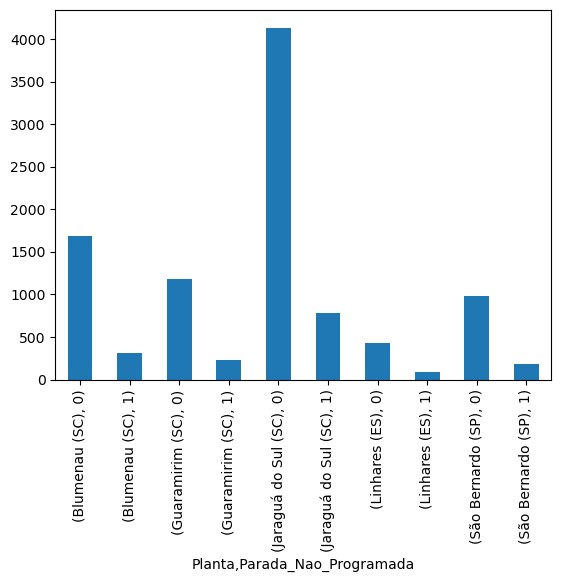

In [49]:
df.groupby(["Planta", "Parada_Nao_Programada"]).size().plot.bar()

In [50]:
df.groupby(["Contrato_Manutencao", "Parada_Nao_Programada"]).size()

Contrato_Manutencao  Parada_Nao_Programada
0                    0                        2127
                     1                         678
1                    0                        6278
                     1                         917
dtype: int64

<Axes: xlabel='Contrato_Manutencao,Parada_Nao_Programada'>

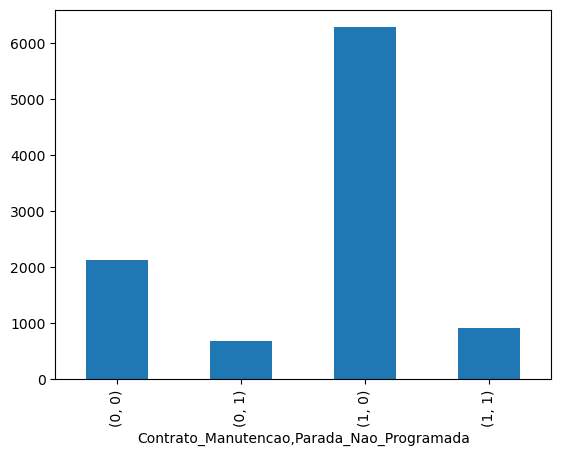

In [51]:
df.groupby(["Contrato_Manutencao", "Parada_Nao_Programada"]).size().plot.bar()

In [52]:
df.head()

,Id,Planta,Linha,Turno,Horas_Operacao,Tempo_Operacao_Anos,Temperatura,Vibracao,Pressao_VPI,Confiabilidade,Contrato_Manutencao,Custo_Manutencao,Parada_Nao_Programada
0,WEG-EQP-00001,Jaraguá do Sul (SC),W12 - Comercial/Residencial,Turno 2 (14:18-23:30),13191.3,15.0,70.1,11.20,5.45,529.0,1,115325.56,1
1,WEG-EQP-00002,Linhares (ES),W22 Magnet,Turno 2 (14:18-23:30),7889.6,4.0,69.1,6.76,8.29,665.0,1,84664.64,1
2,WEG-EQP-00003,Guaramirim (SC),W50 - Alta Tensão,Turno 2 (14:18-23:30),37611.5,5.0,72.1,2.55,6.89,694.0,1,90032.94,0
3,WEG-EQP-00004,Blumenau (SC),W22 - Trifásico Standard,Turno 2 (14:18-23:30),24603.6,14.0,83.7,13.68,5.36,591.0,1,142879.69,0
4,WEG-EQP-00005,Jaraguá do Sul (SC),W22 - Trifásico Standard,Turno 1 (05:00-14:18),60458.4,5.0,71.3,3.33,10.58,609.0,1,89678.02,0
